# HMDF-kNN: tutorial amigable

Este notebook explica el método final sin requerir imágenes médicas, GPU ni checkpoints. Generaremos cuatro vistas sintéticas que representan embeddings de distintas capas de una CNN.

La regla metodológica central es simple:

- **train** guarda los vecinos de referencia;
- **validation** selecciona capas, pesos y `k`;
- **test** se usa una sola vez después de congelar la configuración.

In [1]:
from pathlib import Path
import sys

root = Path.cwd()
if not (root / 'models').exists():
    root = root.parent
sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

from models.hmdf_knn import HMDFKNN

print('Repository root:', root)

Repository root: C:\Users\jesqu\Desktop\Tesis\Tesis_2026\github_release\HMDF-kNN


## 1. Crear embeddings multicapa

Cada muestra tendrá cuatro representaciones. Algunas vistas serán más informativas que otras, reproduciendo el problema que HMDF-kNN intenta resolver: no asumir que la última capa siempre es la única representación útil.

In [2]:
rng = np.random.default_rng(7)
n_classes = 3
latent_dim = 12
centers = rng.normal(size=(n_classes, latent_dim))

def make_split(samples_per_class):
    labels = np.repeat(np.arange(n_classes), samples_per_class)
    latent = centers[labels] + rng.normal(scale=0.6, size=(len(labels), latent_dim))
    views = [
        latent[:, :4] + rng.normal(scale=0.5, size=(len(labels), 4)),
        latent[:, :8] + rng.normal(scale=0.25, size=(len(labels), 8)),
        latent + rng.normal(scale=0.15, size=latent.shape),
        rng.normal(size=(len(labels), 6)),
    ]
    return views, labels

train_views, y_train = make_split(20)
val_views, y_val = make_split(8)
test_views, y_test = make_split(8)
view_names = ['early', 'middle', 'deep', 'final']

[(name, view.shape) for name, view in zip(view_names, train_views)]

[('early', (60, 4)),
 ('middle', (60, 8)),
 ('deep', (60, 12)),
 ('final', (60, 6))]

## 2. Selección usando solamente validation

El método primero evalúa cada capa por separado. Después ordena las capas, forma prefijos rankeados y prueba pesos uniformes, basados en score y candidatos Dirichlet reproducibles.

In [3]:
model = HMDFKNN(
    k_grid=(1, 3, 5, 7, 11),
    max_views=4,
    weight_powers=(0.5, 1.0, 2.0),
    dirichlet_trials=8,
    seed=42,
)
model.fit(train_views, y_train, val_views, y_val, view_names=view_names)

model.selection_

HMDFSelection(layer_indices=[2], layer_names=['deep'], dimensions=[12], weights=[1.0], weighting='dirichlet_07', k=1, validation_metrics={'accuracy': 1.0, 'f1_macro': 1.0, 'balanced_accuracy': 1.0, 'precision_macro': 1.0, 'recall_macro': 1.0}, candidate_count=185, seed=42)

La configuración anterior ya está congelada. A partir de este punto no se cambian capas, pesos ni `k` mirando test.

In [4]:
ranking = pd.DataFrame(model.layer_ranking_)
ranking[['layer_name', 'dim', 'k', 'val_f1_macro', 'val_balanced_accuracy', 'val_accuracy']].sort_values(
    ['val_f1_macro', 'val_balanced_accuracy', 'val_accuracy'], ascending=False
)

,layer_name,dim,k,val_f1_macro,val_balanced_accuracy,val_accuracy
2,deep,12,1,1.000000,1.000000,1.000000
1,middle,8,1,0.958170,0.958333,0.958333
0,early,4,11,0.784392,0.791667,0.791667
3,final,6,3,0.232414,0.250000,0.250000


## 3. Inspeccionar la búsqueda reproducible

Con cuatro vistas, los valores predeterminados producen 185 candidatos de validation. El test no aparece en esta tabla.

In [5]:
candidates = pd.DataFrame(model.validation_candidates_)
print('Validation candidates:', len(candidates))
print('Any test column:', any(column.startswith('test_') for column in candidates.columns))

candidates.sort_values(
    ['val_f1_macro', 'val_balanced_accuracy', 'val_accuracy', 'final_dim'],
    ascending=[False, False, False, True],
).head(10)[['layer_names', 'weighting', 'weights', 'k', 'val_f1_macro', 'val_balanced_accuracy']]

Validation candidates: 185
Any test column: False


,layer_names,weighting,weights,k,val_f1_macro,val_balanced_accuracy
0,[deep],dirichlet_07,[1.0],1,1.0,1.0
1,[deep],dirichlet_07,[1.0],3,1.0,1.0
2,[deep],dirichlet_07,[1.0],5,1.0,1.0
3,[deep],dirichlet_07,[1.0],7,1.0,1.0
4,[deep],dirichlet_07,[1.0],11,1.0,1.0
5,"[deep, middle]",uniform,"[0.5, 0.5]",1,1.0,1.0
6,"[deep, middle]",uniform,"[0.5, 0.5]",3,1.0,1.0
7,"[deep, middle]",uniform,"[0.5, 0.5]",5,1.0,1.0
8,"[deep, middle]",uniform,"[0.5, 0.5]",7,1.0,1.0
9,"[deep, middle]",uniform,"[0.5, 0.5]",11,1.0,1.0


## 4. Evaluación test congelada

In [6]:
test_metrics = model.evaluate(test_views, y_test)
pd.Series(test_metrics, name='test')

accuracy             1.0
f1_macro             1.0
balanced_accuracy    1.0
precision_macro      1.0
recall_macro         1.0
Name: test, dtype: float64

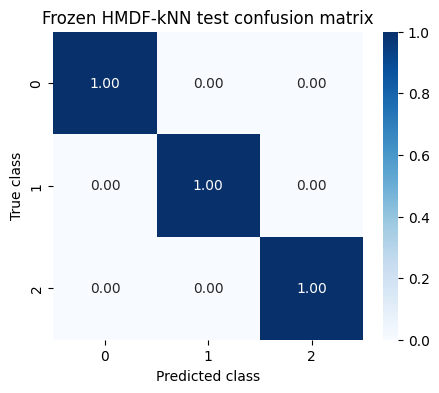

In [7]:
predictions = model.predict(test_views)
matrix = confusion_matrix(y_test, predictions, normalize='true')

plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Frozen HMDF-kNN test confusion matrix')
plt.show()

## 5. Ejecutar con embeddings reales

Cuando tengas un perfil con `train`, `val` y `test`:

```bash
python data/prepare_data.py --profile /path/to/profile
python pipelines/run_hmdf.py --profile /path/to/profile --output results/runs/example
```

El ejecutor exacto de todos los métodos comparativos del paper está en `pipelines/run_raw_literature_multidim_competitors.py`. Las adaptaciones de literatura se describen en `docs/METHOD_ADAPTATIONS.md`.

## Qué demuestra este notebook

- HMDF-kNN fusiona **distancias**, no logits ni coordenadas concatenadas.
- La jerarquía proviene del ranking de capas y de los prefijos rankeados.
- Los pesos Dirichlet son un conjunto finito y reproducible, no aleatoriedad durante test.
- La selección se realiza con validation.
- Test se evalúa después de congelar la configuración.